# Glutamate tuning QC

Inspect image preference calls among image-activated synapses.

In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PNW_cmap import PNW_cmap
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry


sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [8]:
%matplotlib notebook

In [57]:
save_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-03-17_OPhys_LabMeetingIV\figures"

In [4]:
analysis_dir = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-03_09-22-19\analysis') / 'derived' / 'glutamate' /'glutamate_analysis'
tuning_per_image = pd.read_parquet(analysis_dir / 'tuning_per_image_table.parquet')
tuning_summary = pd.read_parquet(analysis_dir / 'tuning_summary_table.parquet')
tuning_summary.head()

,session_id,subject_id,dmd,synapse_id,n_image_trials,n_images_tested,fve_image,p_shuffle_fve,p_kw,preferred_image,preferred_mean,preferred_median,preferred_vs_rest_effect,preferred_vs_next_effect,is_tuned,q_shuffle_fve,q_kw
0,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,2351,7,0.014374,0.000999,4.178503e-07,imk01220,93.606047,101.874824,101.874824,55.960643,False,0.005495,0.000005
1,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0004,2351,7,0.008904,0.002997,2.614581e-03,imk01057,73.658521,53.407176,53.407176,24.428737,False,0.010989,0.007190
2,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0007,2351,7,0.003300,0.259740,2.467986e-01,imk00459,22.009269,0.850114,-0.078267,0.127263,False,0.333333,0.278394
3,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0009,2351,7,0.002260,0.489510,2.378272e-01,imk00459,75.481945,18.634213,12.416760,15.921768,False,0.489510,0.278394
4,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0012,2351,7,0.008023,0.006993,2.170904e-03,imk01643,47.933194,0.094905,-5.162725,3.521669,False,0.019231,0.007190


In [5]:
display(tuning_summary.sort_values('fve_image', ascending=False).head(20))

,session_id,subject_id,dmd,synapse_id,n_image_trials,n_images_tested,fve_image,p_shuffle_fve,p_kw,preferred_image,preferred_mean,preferred_median,preferred_vs_rest_effect,preferred_vs_next_effect,is_tuned,q_shuffle_fve,q_kw
0,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,2351,7,0.014374,0.000999,4.178503e-07,imk01220,93.606047,101.874824,101.874824,55.960643,False,0.005495,0.000005
7,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0032,2351,7,0.011641,0.000999,2.396270e-04,imk00459,79.913316,29.924726,28.835528,26.712270,False,0.005495,0.001318
1,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0004,2351,7,0.008904,0.002997,2.614581e-03,imk01057,73.658521,53.407176,53.407176,24.428737,False,0.010989,0.007190
4,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0012,2351,7,0.008023,0.006993,2.170904e-03,imk01643,47.933194,0.094905,-5.162725,3.521669,False,0.019231,0.007190
6,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0024,2351,7,0.007178,0.010989,1.175941e-02,imk01097,57.350173,45.466214,45.466214,0.797365,False,0.024176,0.025871
9,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0039,2351,7,0.006261,0.019980,3.949197e-02,imk01057,62.831475,38.091766,38.091766,23.169598,False,0.036630,0.062059
10,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0040,2351,7,0.004108,0.151848,2.530852e-01,imk01057,45.745631,38.869859,38.869859,2.062874,False,0.238619,0.278394
2,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0007,2351,7,0.003300,0.259740,2.467986e-01,imk00459,22.009269,0.850114,-0.078267,0.127263,False,0.333333,0.278394
5,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0021,2351,7,0.003217,0.272727,3.614612e-01,imk01057,45.407750,13.435891,13.435891,0.232625,False,0.333333,0.361461
8,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0033,2351,7,0.002575,0.426573,2.640903e-02,imk01057,55.787145,55.687860,55.687860,26.109224,False,0.469231,0.048417


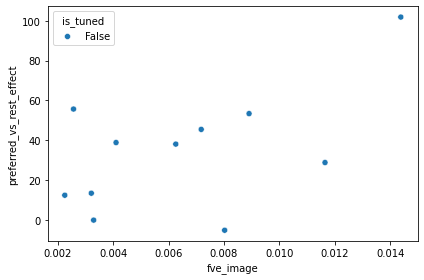

In [6]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=tuning_summary, x='fve_image', y='preferred_vs_rest_effect', hue='is_tuned')
plt.tight_layout()

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_trials,mean_response,median_response,std_response
0,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,stimuli\images_A\imk00459.tiff,imk00459,324,37.645404,2.077952,236.470471
1,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,stimuli\images_A\imk00942.tiff,imk00942,333,14.942116,5.052862,279.166868
2,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,stimuli\images_A\imk01057.tiff,imk01057,365,21.913932,5.666722,250.982003
3,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,stimuli\images_A\imk01097.tiff,imk01097,330,16.146759,0.000000,294.146196
4,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,stimuli\images_A\imk01220.tiff,imk01220,350,93.606047,101.874824,284.092913
5,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,stimuli\images_A\imk01378.tiff,imk01378,332,-17.596577,0.000000,244.312765
6,834788_2026-03-03_09-22-19,834788,DMD1,DMD1_syn0000,stimuli\images_A\imk01643.tiff,imk01643,317,18.164746,0.000000,247.399323


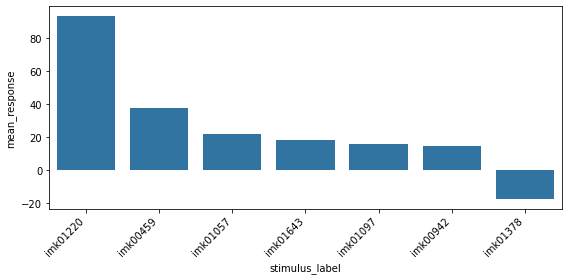

In [7]:
example = tuning_summary.sort_values('fve_image', ascending=False).iloc[0]
sub = tuning_per_image.query('dmd == @example.dmd and synapse_id == @example.synapse_id')
plt.figure(figsize=(8, 4))
sns.barplot(data=sub.sort_values('mean_response', ascending=False), x='stimulus_label', y='mean_response')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sub

<IPython.core.display.Javascript object>


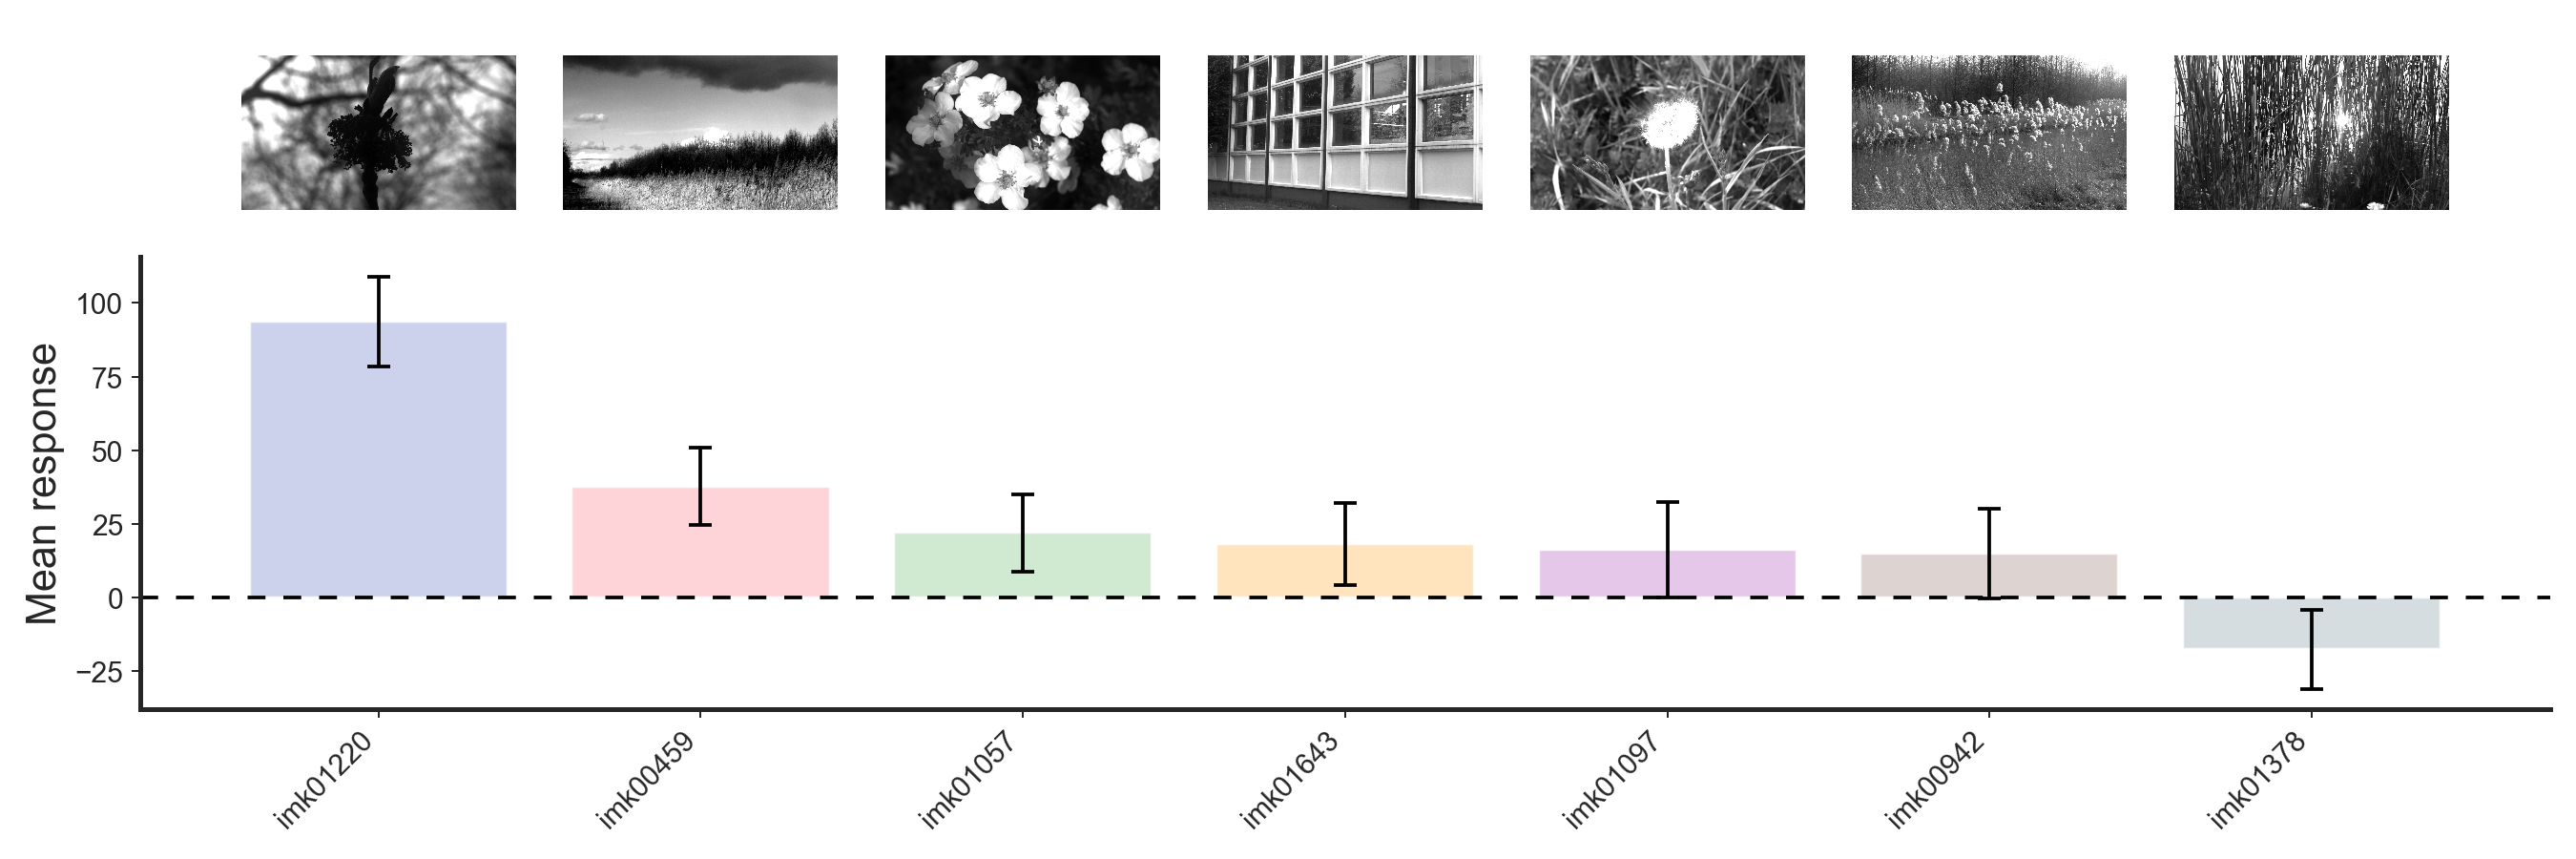

In [35]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

# ---------------------------------------
# inputs
# ---------------------------------------
stim_root = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\Aind.Behavior.ChangeDetection\src\stimuli")

example = tuning_summary.sort_values('fve_image', ascending=False).iloc[0]
sub = tuning_per_image.query(
    'dmd == @example.dmd and synapse_id == @example.synapse_id'
).copy()

# sort bars however you want
sub = sub.sort_values('mean_response', ascending=False).reset_index(drop=True)

# ---------------------------------------
# colors by image identity
# reuses your existing image colors if available
# ---------------------------------------
if 'colors' in globals() and len(colors) >= len(sub['stimulus_label'].unique()):
    image_palette = {
        im: colors[i]
        for i, im in enumerate(sub['stimulus_label'].unique())
    }
else:
    # fallback pastel palette
    fallback_colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
                       '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']
    image_palette = {
        im: fallback_colors[i % len(fallback_colors)]
        for i, im in enumerate(sub['stimulus_label'].unique())
    }

bar_colors = [image_palette[x] for x in sub['stimulus_label']]

# ---------------------------------------
# image lookup helper
# ---------------------------------------
def find_stimulus_image(stim_name, stim_root):
    """
    Recursively find a tif/tiff image whose stem or filename matches stim_name.
    """
    stim_name = str(stim_name).strip()
    candidates = []
    for ext in ("*.tif", "*.tiff", "*.TIF", "*.TIFF"):
        candidates.extend(stim_root.rglob(ext))

    # first try exact stem match
    exact = [p for p in candidates if p.stem == stim_name]
    if exact:
        return exact[0]

    # then exact filename without extension contained in path stem
    exact_casefold = [p for p in candidates if p.stem.lower() == stim_name.lower()]
    if exact_casefold:
        return exact_casefold[0]

    # fallback substring match
    partial = [p for p in candidates if stim_name.lower() in p.stem.lower()]
    if partial:
        return partial[0]

    return None

# ---------------------------------------
# determine error bars
# ---------------------------------------
# preferred: std_response already in table
if 'std_response' in sub.columns:
    yerr = sub['std_response'].to_numpy(dtype=float)/np.sqrt(sub['n_trials']).to_numpy(dtype=float)

# fallback: derive from per-trial response arrays if present
elif 'responses' in sub.columns:
    def _safe_std(x):
        try:
            arr = np.asarray(x, dtype=float)
            return np.nanstd(arr)
        except Exception:
            return np.nan
    yerr = sub['responses'].apply(_safe_std).to_numpy(dtype=float)

else:
    yerr = None
    print("No std_response or responses column found; plotting without error bars.")

# ---------------------------------------
# plot
# ---------------------------------------
fig, ax = plt.subplots(figsize=(15, 5))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

x = np.arange(len(sub))
y = sub['mean_response'].to_numpy(dtype=float)

bars = ax.bar(
    x,
    y,
    color=bar_colors,
    edgecolor=None,
    linewidth=1.0,
    alpha=0.85,
    yerr=yerr,
    capsize=5,
    error_kw=dict(lw=1.5, capthick=1.5, ecolor='k')
)

# clean x labels
ax.set_xticks(x)
ax.set_xticklabels(sub['stimulus_label'], rotation=45, ha='right')

ax.set_ylabel('Mean response')
ax.set_xlabel('')
# ax.set_title(
#     f"DMD {example.dmd} | synapse {example.synapse_id} | image tuning"
# )

sns.despine()
fig.tight_layout()

# ---------------------------------------
# add stimulus images above each bar
# ---------------------------------------
# leave vertical room for thumbnails
ymax = np.nanmax(y + (yerr if yerr is not None else 0))
ymin = min(0, np.nanmin(y))
yr = ymax - ymin if ymax > ymin else 1.0
# ax.set_ylim(ymin, ymax + 0.55 * yr)

for i, stim_name in enumerate(sub['stimulus_label']):
    img_path = find_stimulus_image(stim_name, stim_root)

    if img_path is None:
        print(f"Could not find image for stimulus: {stim_name}")
        continue

    try:
        img = mpimg.imread(img_path)
    except Exception as e:
        print(f"Could not load {img_path}: {e}")
        continue

    image_y = ymax + 0.18 * yr

    if img.ndim == 3:
        img = img.mean(axis=2)

    img = img.astype(float)
    img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-9)

    imagebox = OffsetImage(
        img,
        zoom=0.06,
        cmap="gray",
    )

    ab = AnnotationBbox(
        imagebox,
        (x[i], image_y),
        frameon=False,
        pad=0.2,
        box_alignment=(0.5, 0.0),
        annotation_clip=False,
    )
    ax.add_artist(ab)

# optional: remove legend since bar colors correspond directly to x labels
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
    
ax.axhline(0,color='k',dashes = [5,5])
fig.tight_layout()

In [39]:
import os
import glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [47]:
def normalize_dmd(x):
    s = str(x).strip().upper()
    if s in {"1", "1.0", "DMD1"}:
        return 1
    elif s in {"2", "2.0", "DMD2"}:
        return 2
    return np.nan


def infer_dmd_depth_map(asset):
    meta = getattr(asset, "metadata", {}) or {}
    return {
        1: pd.to_numeric(meta.get("dmd1_depth", np.nan), errors="coerce"),
        2: pd.to_numeric(meta.get("dmd2_depth", np.nan), errors="coerce"),
    }


def find_tuning_summary_table(asset):
    """
    Prefer CSV because in your dataset it is more likely to retain dmd explicitly.
    Fall back to parquet.
    """
    search_roots = [
        getattr(asset, "derived_dir", None),
        getattr(asset, "qc_dir", None),
        getattr(asset, "session_dir", None),
    ]

    patterns = [
        "tuning_summary_table.csv",
        "tuning_summary_table.parquet",
        "*tuning*summary*.csv",
        "*tuning*summary*.parquet",
    ]

    matches = []
    for root in search_roots:
        if root is None:
            continue
        root = Path(root)
        for pat in patterns:
            matches.extend(glob.glob(str(root / "**" / pat), recursive=True))

    matches = sorted(set(matches))
    if not matches:
        return None

    csv_matches = [m for m in matches if m.lower().endswith(".csv")]
    if csv_matches:
        return Path(max(csv_matches, key=os.path.getmtime))

    parquet_matches = [m for m in matches if m.lower().endswith(".parquet")]
    if parquet_matches:
        return Path(max(parquet_matches, key=os.path.getmtime))

    return None


def read_table(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    elif path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported table type: {path}")


def get_asset_session_metadata(asset):
    """
    Prefer metadata from the asset/session registry.
    """
    meta = getattr(asset, "metadata", {}) or {}

    return {
        "session_id": getattr(asset, "session_id", meta.get("session_id", np.nan)),
        "subject_id": getattr(asset, "subject_id", meta.get("subject_id", np.nan)),
        "session_type": meta.get("session_type", np.nan),
        "session_date": meta.get("session_date", np.nan),
        "paradigm": meta.get("paradigm", np.nan),
        "session_dir": str(getattr(asset, "session_dir", "")),
    }

In [49]:
def build_tuning_summary_df(assets):
    dfs = []
    skipped = []

    for asset in assets:
        session_dir = str(getattr(asset, "session_dir", "UNKNOWN_SESSION_DIR"))

        try:
            table_path = find_tuning_summary_table(asset)
            if table_path is None:
                print(f"[skip] no tuning summary table found: {session_dir}")
                skipped.append(session_dir)
                continue

            df = read_table(table_path).copy()
            if df.empty:
                print(f"[skip] empty tuning summary table: {session_dir}")
                skipped.append(session_dir)
                continue

            # require selectivity column
            if "is_tuned" not in df.columns:
                print(f"[skip] missing is_tuned column: {session_dir}")
                skipped.append(session_dir)
                continue

            # require a synapse identifier
            syn_id_col = None
            for candidate in ["synapse_id", "roi_id", "roi", "synapse"]:
                if candidate in df.columns:
                    syn_id_col = candidate
                    break

            if syn_id_col is None:
                print(f"[skip] no synapse identifier column found: {session_dir}")
                print("columns:", df.columns.tolist())
                skipped.append(session_dir)
                continue

            # require dmd in table; if absent, skip rather than trying to infer unreliably
            if "dmd" not in df.columns:
                print(f"[skip] missing dmd column: {session_dir}")
                print(f"       file: {table_path}")
                skipped.append(session_dir)
                continue

            dmd_depth_map = infer_dmd_depth_map(asset)
            session_meta = get_asset_session_metadata(asset)

            df["dmd_norm"] = df["dmd"].apply(normalize_dmd)
            df["depth_um"] = df["dmd_norm"].map(dmd_depth_map)

            if df["dmd_norm"].isna().all():
                print(f"[skip] could not normalize dmd column: {session_dir}")
                print("unique raw dmd values:", pd.unique(df["dmd"]))
                skipped.append(session_dir)
                continue

            if df["depth_um"].isna().all():
                print(f"[skip] all depth_um are NaN after mapping: {session_dir}")
                print("depth map:", dmd_depth_map)
                print("unique raw dmd:", pd.unique(df["dmd"]))
                print("unique normalized dmd:", pd.unique(df["dmd_norm"]))
                skipped.append(session_dir)
                continue

            # attach session metadata from asset
            df["session_id"] = session_meta["session_id"]
            df["subject_id"] = session_meta["subject_id"]
            df["session_type"] = session_meta["session_type"]
            df["session_date"] = session_meta["session_date"]
            df["paradigm"] = session_meta["paradigm"]
            df["session_dir"] = session_meta["session_dir"]
            df["tuning_summary_path"] = str(table_path)
            df["_synapse_id_col_used"] = syn_id_col
            df["_synapse_id"] = df[syn_id_col]

            dfs.append(df)

        except Exception as e:
            print(f"[skip] failed to process: {session_dir}")
            print(f"       reason: {repr(e)}")
            skipped.append(session_dir)
            continue

    if not dfs:
        raise ValueError("No usable tuning summary tables were loaded.")

    out = pd.concat(dfs, ignore_index=True)

    if "session_date" in out.columns:
        out["session_date"] = pd.to_datetime(out["session_date"], errors="coerce")

    out["depth_um"] = pd.to_numeric(out["depth_um"], errors="coerce")
    out["is_tuned"] = out["is_tuned"].astype(bool)

    return out, skipped

In [51]:
tuning_df, skipped_tuning_sessions = build_tuning_summary_df(assets)

print("tuning_df shape:", tuning_df.shape)
print("n skipped sessions:", len(skipped_tuning_sessions))

display(
    tuning_df[
        [
            "subject_id", "session_id", "session_type", "session_date",
            "dmd", "dmd_norm", "depth_um", "_synapse_id", "is_tuned"
        ]
    ].head(20)
)

print("\nDepth counts:")
print(tuning_df["depth_um"].value_counts(dropna=False).sort_index())

print("\nSession type counts:")
print(tuning_df["session_type"].value_counts(dropna=False))

[skip] empty tuning summary table: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\809047\2025-11-06_809047
[skip] empty tuning summary table: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-17_15-17-36
[skip] empty tuning summary table: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-20_12-44-00
[skip] empty tuning summary table: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-03_13-49-07
[skip] empty tuning summary table: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-18_16-43-23
[skip] empty tuning summary table: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\838410\838410_2026-03-19_13-06-48
tuning_df shape: (2658, 26)
n skipped sessions: 6


,subject_id,session_id,session_type,session_date,dmd,dmd_norm,depth_um,_synapse_id,is_tuned
0,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0002,False
1,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0003,False
2,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0005,True
3,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0006,False
4,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0007,False
5,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0008,False
6,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0009,False
7,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0010,True
8,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0011,False
9,803496,803496_2025-07-25_13-02-10,familiar,2025-07-25,DMD1,1,25,DMD1_syn0012,True



Depth counts:
depth_um
25     1265
100     656
200     396
250     341
Name: count, dtype: int64

Session type counts:
session_type
familiar    1226
novel+       941
novel        491
Name: count, dtype: int64


In [52]:
plot_df = tuning_df.copy()

plot_df["selectivity_class"] = np.where(
    plot_df["is_tuned"],
    "selective",
    "non_selective"
)

dedup_cols = ["subject_id", "session_id", "depth_um", "_synapse_id"]

plot_df = (
    plot_df
    .sort_values(["subject_id", "session_date", "session_id"])
    .drop_duplicates(dedup_cols)
    .copy()
)

display(
    plot_df[
        ["subject_id", "session_id", "session_type", "depth_um", "_synapse_id", "selectivity_class"]
    ].head(20)
)

,subject_id,session_id,session_type,depth_um,_synapse_id,selectivity_class
1979,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0000,non_selective
1980,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0006,non_selective
1981,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0007,selective
1982,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0010,non_selective
1983,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0011,non_selective
1984,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0012,selective
1985,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0017,selective
1986,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0018,non_selective
1987,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0019,non_selective
1988,803121,803121_2025-10-29_11-19-29,familiar,200,DMD1_syn0021,non_selective


<IPython.core.display.Javascript object>


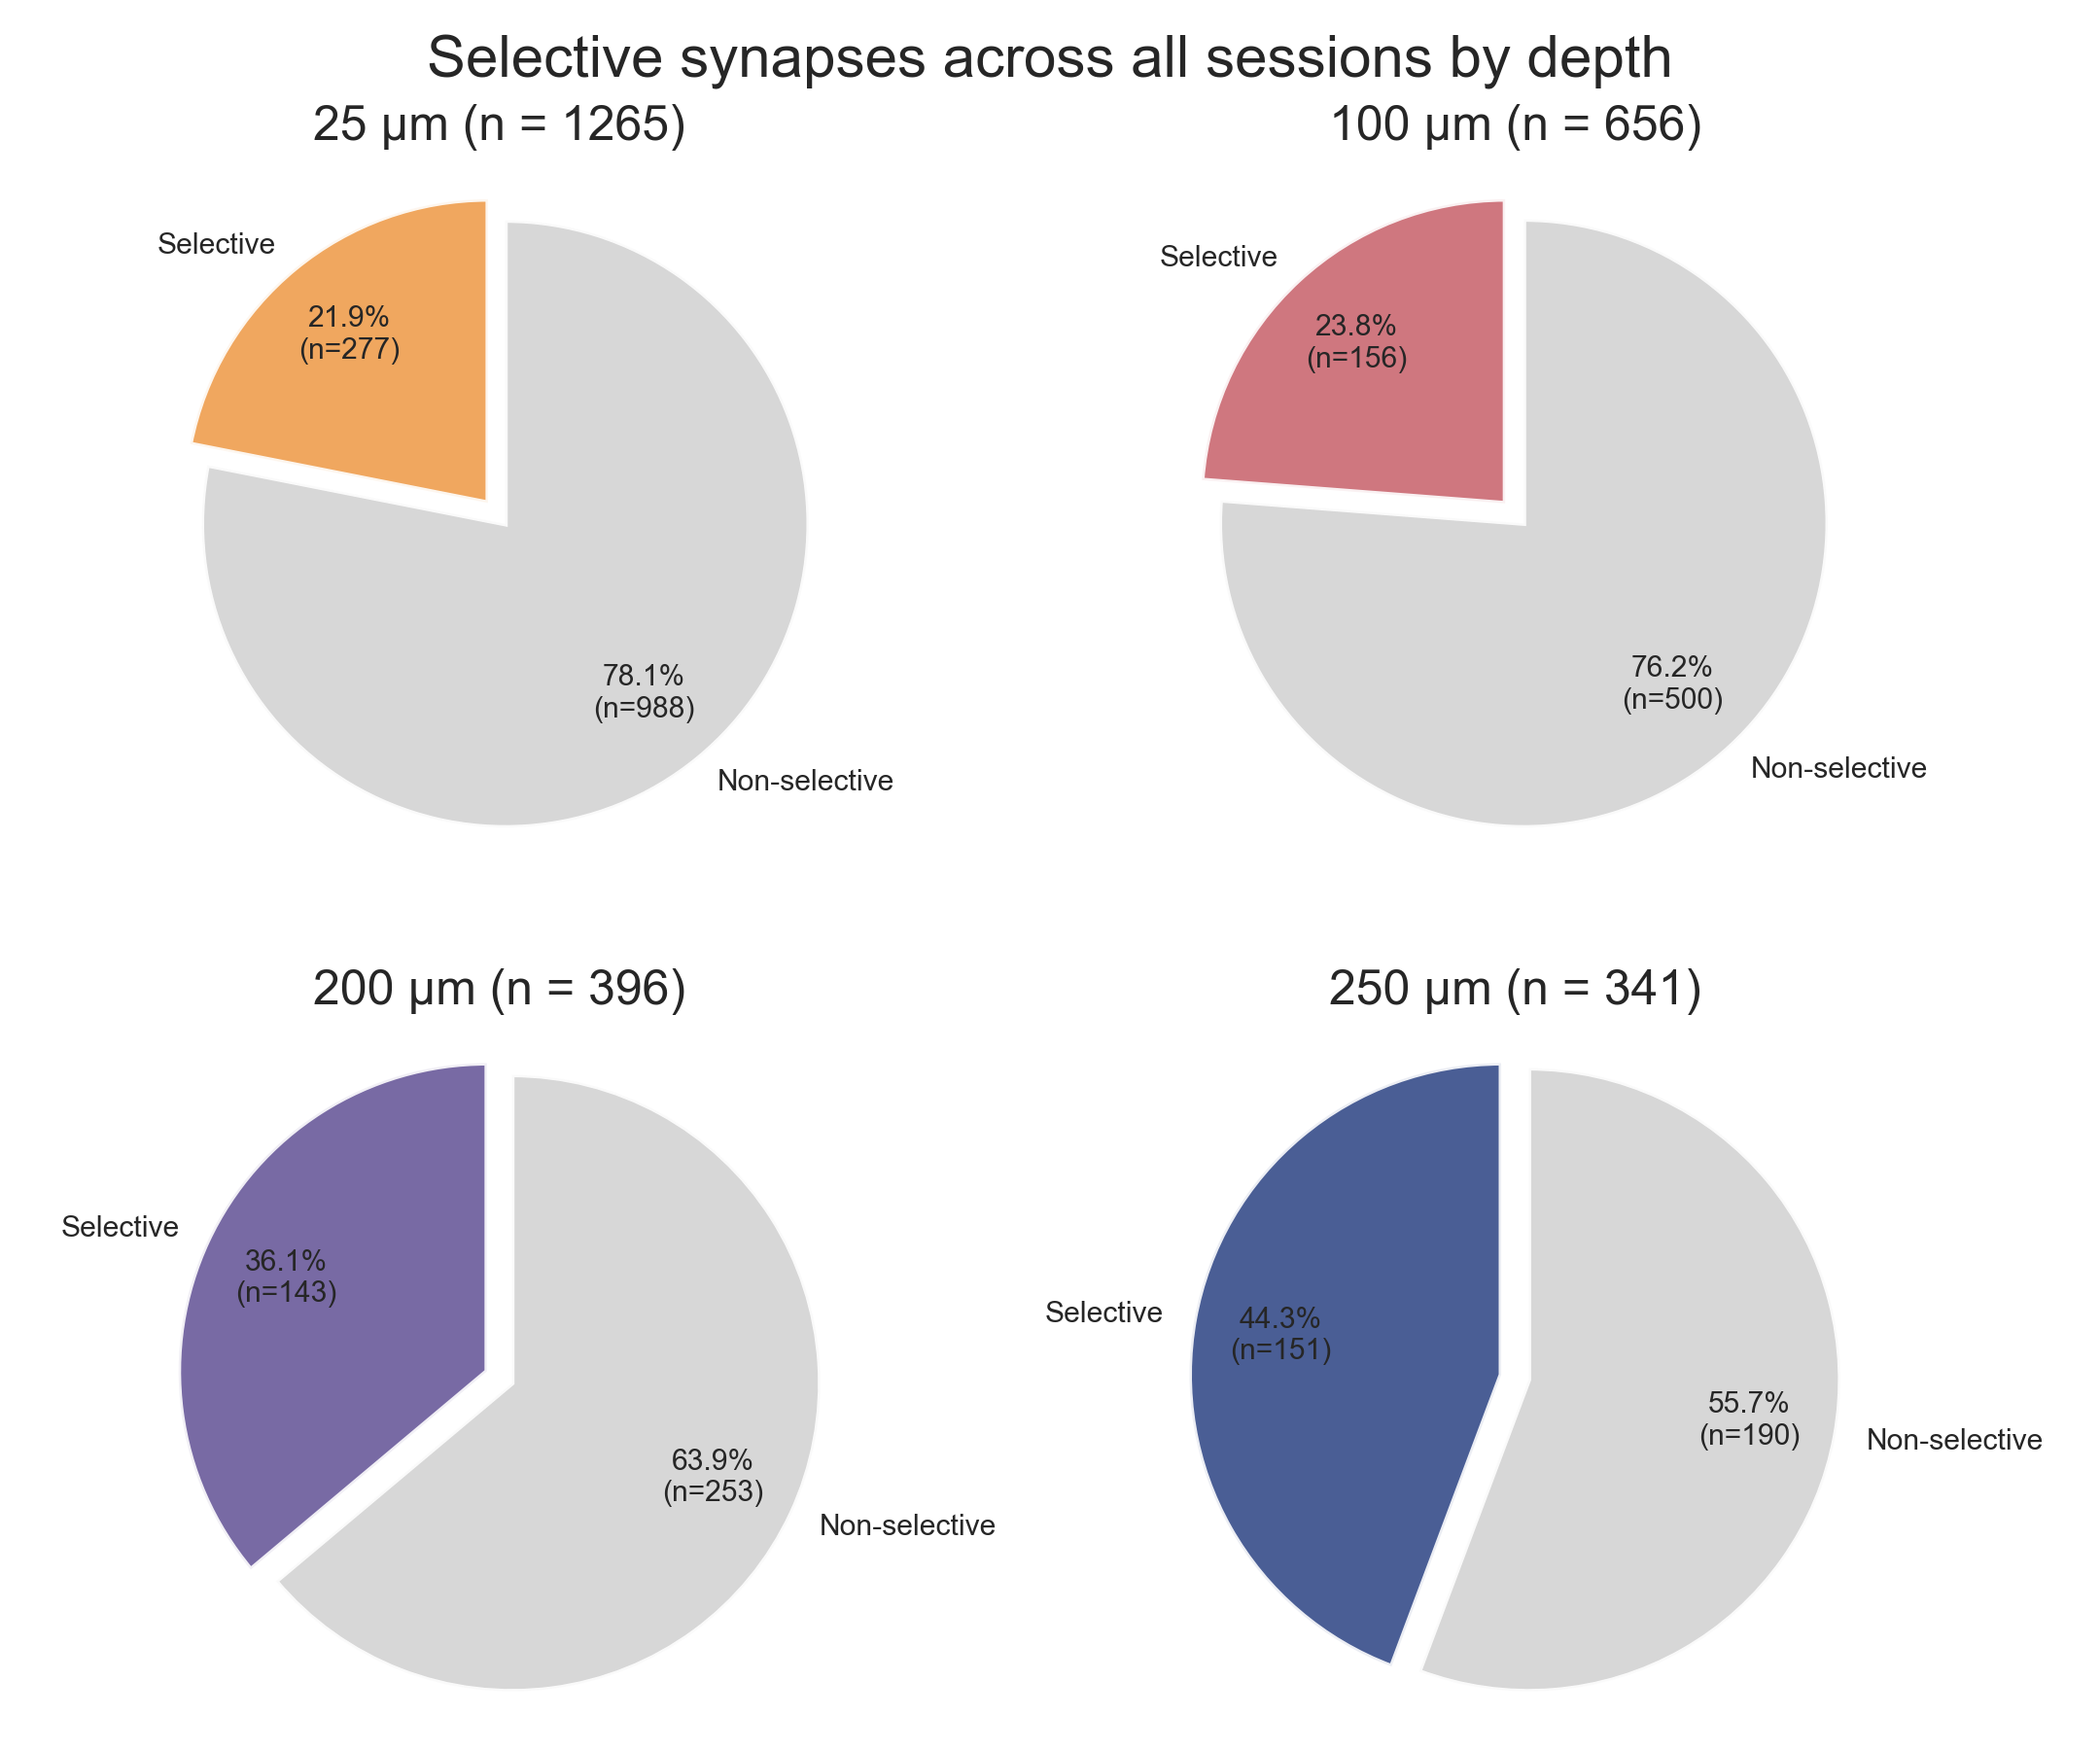

In [59]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sunset2', n_colors=10)
cp = [cp[::-1][0], cp[::-1][4], cp[::-1][7], cp[::-1][9]]

depth_order = [25, 100, 200, 250]
depth_color_map = dict(zip(depth_order, cp))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
axes = ax.flatten()

for i, depth in enumerate(depth_order):
    axis = axes[i]
    sub = plot_df[plot_df["depth_um"] == depth].copy()

    counts = Counter(sub["selectivity_class"].values)

    order = ["selective", "non_selective"]
    sizes = [counts.get(c, 0) for c in order]
    total_n = sum(sizes)

    def _autopct(pct):
        n = int(round(pct * total_n / 100.0))
        return f"{pct:.1f}%\n(n={n})" if n > 0 else ""

    axis.pie(
        sizes,
        labels=["Selective", "Non-selective"],
        colors=[depth_color_map[depth], "lightgray"],
        explode=[0.06, 0.03],
        startangle=90,
        counterclock=True,
        autopct=_autopct,
        pctdistance=0.72,
        labeldistance=1.10,
        wedgeprops=dict(edgecolor="w", linewidth=2, alpha=0.9),
        textprops=dict(fontsize=12),
    )

    axis.set_title(f"{depth} µm (n = {total_n})", fontsize=20, y=1.02)
    axis.axis("equal")

fig.suptitle("Selective synapses across all sessions by depth", fontsize=24, y=0.98)
fig.tight_layout()
fig.subplots_adjust(hspace=0.25, wspace=0.15)

filen = f"SelectivePie_ByDepth"
savepath = os.path.join(save_path, filen)
save_figure(fig, savepath, formats=[".pdf", ".png"], dpi=300)

In [66]:
a_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-03-17_OPhys_LabMeetingIV\figures\activation_df.csv"
activation_image_df = pd.read_csv(a_path)

,subject_id,session_id,session_type,session_slot
51,838410,838410_2026-03-20_10-00-59,n+,n
52,838410,838410_2026-03-18_16-43-23,n,n+1


<IPython.core.display.Javascript object>


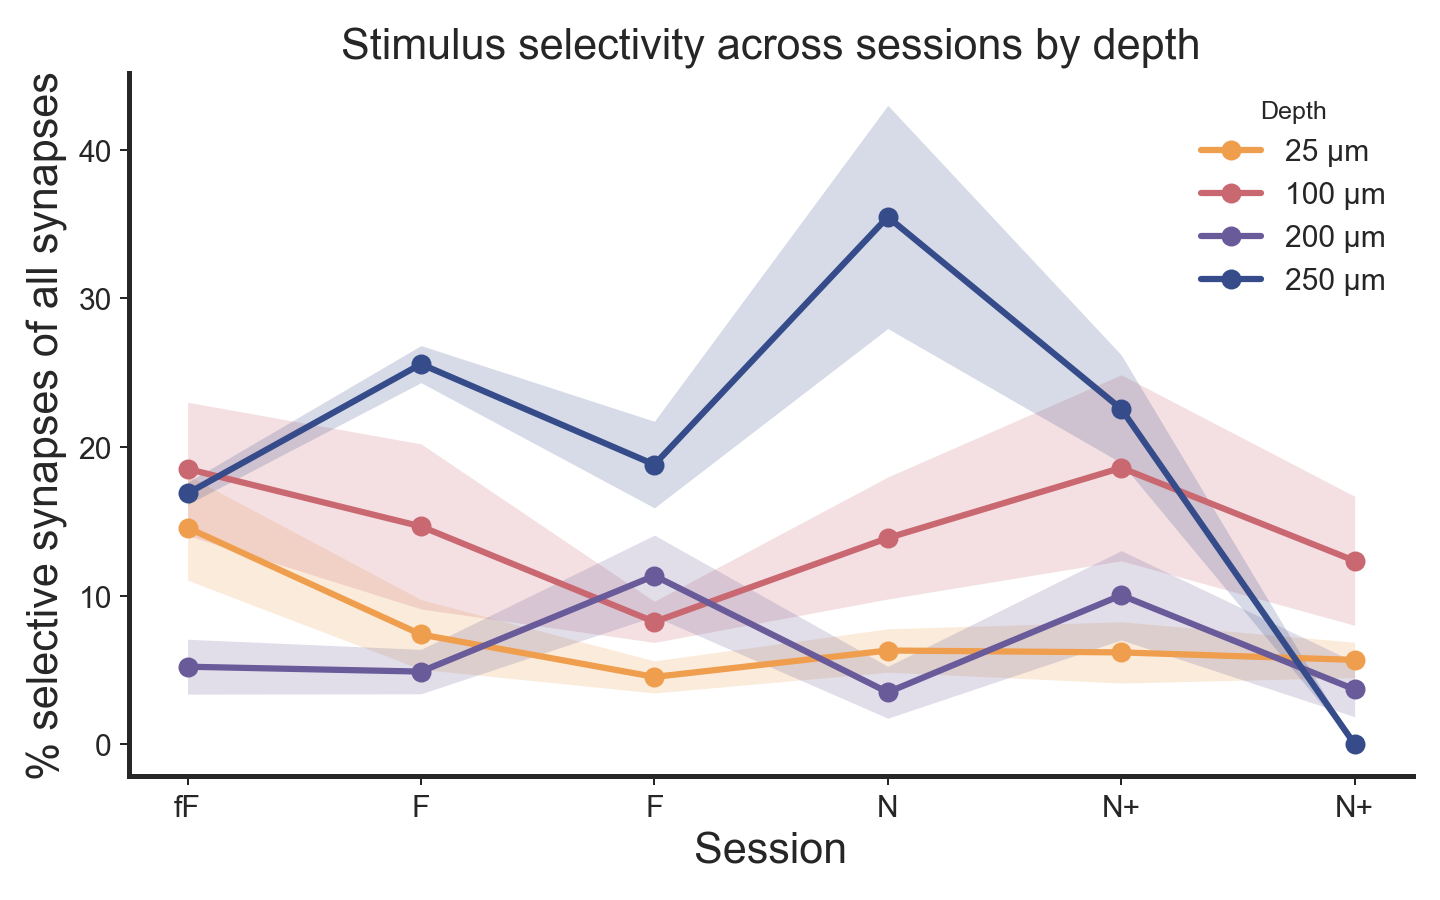

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# colors
# -----------------------------------------
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sunset2', n_colors=10)
cp = [cp[::-1][0], cp[::-1][4], cp[::-1][7], cp[::-1][9]]

depth_order = [25, 100, 200, 250]
depth_color_map = dict(zip(depth_order, cp))

slot_order = ["f1", "f2", "f3", "n", "n+1", "n+2"]
expected_type_by_slot = {
    "f1": "f",
    "f2": "f",
    "f3": "f",
    "n": "n",
    "n+1": "n+",
    "n+2": "n+",
}

# -----------------------------------------
# denominator: all synapses from activation_image_df
# -----------------------------------------
all_df = activation_image_df.copy()

all_df["session_type"] = (
    all_df["session_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "familiar": "f",
        "novel": "n",
        "novel+": "n+",
        "novel_plus": "n+",
    })
)

all_df["session_date"] = pd.to_datetime(all_df["session_date"], errors="coerce")
all_df["depth_um"] = pd.to_numeric(all_df["depth_um"], errors="coerce")
all_df = all_df[all_df["depth_um"].isin(depth_order)].copy()

# collapse to one row per synapse/session/depth
if "synapse_id" not in all_df.columns:
    raise ValueError("activation_image_df must contain synapse_id")

all_df = (
    all_df
    .sort_values(["subject_id", "session_date", "session_id"])
    .drop_duplicates(["subject_id", "session_id", "depth_um", "synapse_id"])
    .copy()
)

# -----------------------------------------
# numerator: selective synapses from tuning plot_df
# plot_df was built from tuning summary and already collapsed to one row per synapse
# -----------------------------------------
sel_df = plot_df.copy()

sel_df["session_type"] = (
    sel_df["session_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "familiar": "f",
        "novel": "n",
        "novel+": "n+",
        "novel_plus": "n+",
    })
)

sel_df["session_date"] = pd.to_datetime(sel_df["session_date"], errors="coerce")
sel_df["depth_um"] = pd.to_numeric(sel_df["depth_um"], errors="coerce")
sel_df = sel_df[sel_df["depth_um"].isin(depth_order)].copy()

sel_df["is_selective"] = sel_df["selectivity_class"].eq("selective")

# keep only selective rows for numerator
sel_df = sel_df[sel_df["is_selective"]].copy()

# -----------------------------------------
# choose last 6 sessions per animal using denominator table
# -----------------------------------------
session_meta = (
    all_df[["subject_id", "session_id", "session_date", "session_type"]]
    .drop_duplicates()
    .sort_values(["subject_id", "session_date", "session_id"])
    .reset_index(drop=True)
)

last6 = (
    session_meta
    .groupby("subject_id", group_keys=False)
    .tail(6)
    .copy()
)

last6 = last6.sort_values(["subject_id", "session_date", "session_id"]).reset_index(drop=True)
last6["session_slot"] = last6.groupby("subject_id").cumcount().map(dict(enumerate(slot_order)))

last6["expected_type"] = last6["session_slot"].map(expected_type_by_slot)
last6["matches_expected"] = last6["session_type"] == last6["expected_type"]

mismatch = last6.loc[
    ~last6["matches_expected"],
    ["subject_id", "session_id", "session_type", "session_slot"]
]
if len(mismatch):
    print("Warning: some animals' last 6 sessions do not match f,f,f,n,n+,n+")
    display(mismatch)

# -----------------------------------------
# attach session slots
# -----------------------------------------
all_df = all_df.merge(
    last6[["subject_id", "session_id", "session_slot"]],
    on=["subject_id", "session_id"],
    how="inner"
)

sel_df = sel_df.merge(
    last6[["subject_id", "session_id", "session_slot"]],
    on=["subject_id", "session_id"],
    how="inner"
)

# -----------------------------------------
# denominator counts: all synapses per animal x slot x depth
# -----------------------------------------
all_counts = (
    all_df
    .groupby(["subject_id", "session_slot", "depth_um"], observed=True)
    .agg(n_all_synapses=("synapse_id", "nunique"))
    .reset_index()
)

# -----------------------------------------
# numerator counts: selective synapses per animal x slot x depth
# -----------------------------------------
# use the same synapse identifier column as in plot_df
sel_syn_col = "_synapse_id" if "_synapse_id" in sel_df.columns else "synapse_id"

sel_counts = (
    sel_df
    .groupby(["subject_id", "session_slot", "depth_um"], observed=True)
    .agg(n_selective_synapses=(sel_syn_col, "nunique"))
    .reset_index()
)

# -----------------------------------------
# combine and compute percent selective of all synapses
# -----------------------------------------
animal_slot_depth = all_counts.merge(
    sel_counts,
    on=["subject_id", "session_slot", "depth_um"],
    how="left"
)

animal_slot_depth["n_selective_synapses"] = animal_slot_depth["n_selective_synapses"].fillna(0)
animal_slot_depth["pct_selective_of_all"] = (
    100 * animal_slot_depth["n_selective_synapses"] / animal_slot_depth["n_all_synapses"]
)

# -----------------------------------------
# summarize across animals with SEM
# -----------------------------------------
summary = (
    animal_slot_depth
    .groupby(["session_slot", "depth_um"], observed=True)
    .agg(
        mean_pct=("pct_selective_of_all", "mean"),
        sd_pct=("pct_selective_of_all", "std"),
        n_animals=("pct_selective_of_all", "count"),
    )
    .reset_index()
)

summary["sem_pct"] = summary["sd_pct"] / np.sqrt(summary["n_animals"])
summary["session_slot"] = pd.Categorical(
    summary["session_slot"],
    categories=slot_order,
    ordered=True,
)
summary = summary.sort_values(["depth_um", "session_slot"])

# -----------------------------------------
# plot
# -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

xpos = np.arange(len(slot_order))
xmap = dict(zip(slot_order, xpos))

for depth in depth_order:
    sub = summary[summary["depth_um"] == depth].copy()
    if sub.empty:
        continue

    x = sub["session_slot"].map(xmap).to_numpy(dtype=float)
    y = sub["mean_pct"].to_numpy(dtype=float)
    sem = sub["sem_pct"].to_numpy(dtype=float)

    ax.plot(
        x,
        y,
        lw=2.5,
        marker="o",
        ms=7,
        color=depth_color_map[depth],
        label=f"{depth} µm",
    )

    ax.fill_between(
        x,
        y - sem/2,
        y + sem/2,
        color=depth_color_map[depth],
        alpha=0.2,
        linewidth=0,
    )

ax.set_xticks(xpos)
ax.set_xticklabels(["fF", "F", "F", "N", "N+", "N+"])
ax.set_xlabel("Session")
ax.set_ylabel("% selective synapses of all synapses")
ax.set_title("Stimulus selectivity across sessions by depth")
ax.legend(frameon=False, title="Depth",fontsize=12)

sns.despine()

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
fig.tight_layout()

filen = f"PctSelectiveOfAll_ByDepth_AcrossSessions"
savepath = os.path.join(save_path, filen)
save_figure(fig, savepath, formats=[".pdf", ".png"], dpi=300)